# ipynb/compare_bar_with_evormd.ipynb - 柱状图对比(含 EvoRMD) / Bar chart comparison (with EvoRMD)

## 项目背景 / Background
柱状图对比(含 EvoRMD)
Bar chart comparison (with EvoRMD)

## 功能模块 / Modules
- 柱状图对比,加入 EvoRMD 模型
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/compare_bar.ipynb、inference_evormd_segmented.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font 

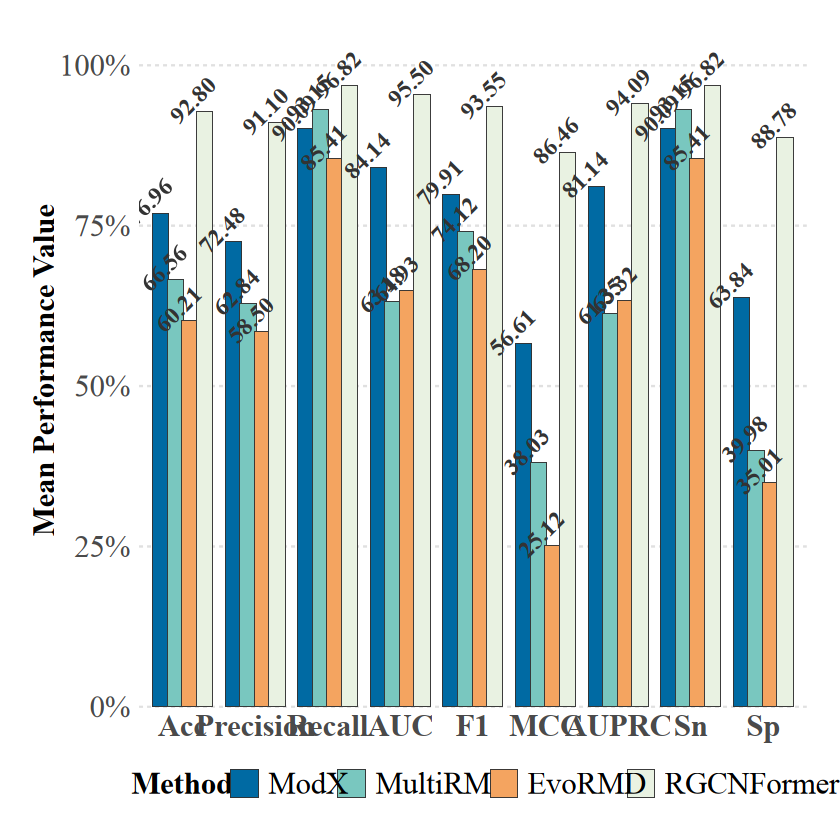

In [9]:
# 1. 安装并加载包
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 2. 注册字体 (禁用showtext_auto以便PDF中字体可编辑)
tryCatch({
  font_add("Times New Roman", 
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf", 
           bold = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  # showtext_auto()  # 禁用，让PDF中的字体在Illustrator中可编辑
}, error = function(e) message("字体加载失败，使用默认字体"))

# --- 1. 数据准备 ---
file_list <- list(
  "ModX" = "data/modx_res.csv",
  "MultiRM" = "data/multirm_res.csv",
  "EvoRMD" = "data/evormd_res.csv",
  "RGCNFormer" = "data/res.csv"
)

metric_levels <- c("Acc", "Precision", "Recall", "AUC", "F1", "MCC", "AUPRC", "Sn", "Sp")

# 读取数据并计算平均值
df_list <- lapply(names(file_list), function(mname) {
  read.csv(file_list[[mname]]) %>%
    summarise(across(all_of(metric_levels), \(x) mean(x, na.rm = TRUE))) %>%
    mutate(Model = mname)
})

# 合并数据并转为长格式
plot_data <- bind_rows(df_list) %>%
  pivot_longer(cols = all_of(metric_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Model = factor(Model, levels = c("ModX", "MultiRM", "EvoRMD", "RGCNFormer"))
  )

# --- 2. 定义指定配色 ---
# 006AA3 (深蓝), 79C7BF (青绿), E9F2E2 (浅绿白), F4A460 (橙棕)
model_palette <- c(
  "ModX" = "#006AA3",
  "MultiRM" = "#79C7BF",
  "EvoRMD" = "#F4A460",
  "RGCNFormer" = "#E9F2E2"
)

# --- 3. 绘图 ---
p_bar <- ggplot(plot_data, aes(x = Metric, y = Value, fill = Model)) +
  # 绘制分组柱状图，position_dodge 让柱子并列
  geom_bar(stat = "identity", 
           position = position_dodge(width = 0.8), 
           color = "#333333", # 给柱子加一个细深色边框增加立体感
           linewidth = 0.2) +
  
  # 添加数值标签 (百分制)
  geom_text(aes(label = sprintf("%.2f", Value * 100)), 
            position = position_dodge(width = 0.8), 
            vjust = -0.5,           # 标签放在柱子上方
            size = 5, 
            fontface = "bold", 
            family = "Times New Roman",
            color = "#333333",
            angle = 45) +
  
  # 设置配色方案
  scale_fill_manual(values = model_palette) +
  
  # 设置Y轴范围和标签格式
  scale_y_continuous(labels = percent_format(), 
                     limits = c(0, 1.05), # 留出顶部空间放标签
                     expand = c(0, 0)) +
  
  # 辅助设置
  theme_minimal() +
  labs(y = "Mean Performance Value", fill = "Method") +
  theme(
    text = element_text(family = "Times New Roman"),
    # 调整坐标轴字体
    axis.text.x = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 18, color = "#4A4A4A"),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 18, face = "bold", margin = margin(r = 10)),
    
    # 网格线设置 (仅保留水平主网格)
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "#E0E0E0", linetype = "dashed"),
    
    # 图例设置
    legend.position = "bottom",
    legend.title = element_text(size = 18, face = "bold"),
    legend.text = element_text(size = 18),
    
    # 边距
    plot.margin = margin(20, 20, 20, 20)
  )

# --- 4. 保存图片 ---
# 4个模型，宽度设为 20 英寸
ggsave("png3/model_comparison_bar_with_evormd.pdf", p_bar, width = 12, height = 4, dpi = 300, device = cairo_pdf)
ggsave("png3/model_comparison_bar_with_evormd.png", p_bar, width = 12, height = 4, dpi = 300)
print(p_bar)